## **Terminologies**

1. State: Shared data structure that represents the current snapshot. The first thing you do when you define a graph is define the State of the graph. The State consists of the schema of the graph as well as reducer functions which specify how to apply updates to the state.
2. Reducer: Reducers are key to understanding how updates from nodes are applied to the State. Each key in the State has its own independent reducer function. If no reducer function is explicitly specified then it is assumed that all updates to that key should override it.
3. Nodes: Contains functional logic in your workflow. Each node receive the current state as input, perform some computation and return the updated state
4. Edges: Can be conditional or fixed transactions. They determine which node to execute next based on current state
5. Superset: A super-step can be considered a single iteration over the graph nodes. Nodes that run in parallel are part of the same super-step, while nodes that run sequentially belong to separate super-steps.
6. Multiple schemas: Typically, all graph nodes communicate with a single schema. This means that they will read and write to the same state channels. But, there are cases where we want more control over this.
```python
graph = StateGraph(
    OverallState,
    input_schema=InputState,
    output_schema=OutputState
)
```

In short: nodes do the work, edges tell what to do next.



### **Default Reducer**

In [1]:
from typing import TypedDict, List

class State(TypedDict):
    foo: int
    bar: List[str]

def node_1(state: State) -> State:
    return {"foo" : 2}

def node_2(state: State) -> State:
    return {"bar": ["bye"]}

In [2]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)

graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)

graph.add_edge(START, "node_1")
graph.add_edge("node_1", "node_2")
graph.add_edge("node_2", END)

workflow = graph.compile()

In [3]:
workflow.invoke({"foo": 1, "bar": ["hi"]})

{'foo': 2, 'bar': ['bye']}

### **Append Reducer**

In this example, we’ve used the Annotated type to specify a reducer function (operator.add) for the second key (bar).

In [4]:
from typing import TypedDict, List, Annotated
from operator import add

class State(TypedDict):
    foo: int
    bar: Annotated[List[str], add]

def node_1(state: State) -> State:
    return {"foo" : 2}

def node_2(state: State) -> State:
    return {"bar": ["bye"]}

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)

graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)

graph.add_edge(START, "node_1")
graph.add_edge("node_1", "node_2")
graph.add_edge("node_2", END)

workflow = graph.compile()

In [6]:
workflow.invoke({"foo": 1, "bar": ["hi"]})

{'foo': 2, 'bar': ['hi', 'bye']}

### **Working with Messages in Graph State - add_messages Reducer**

Most modern LLM providers have a chat model interface that accepts a list of messages as input. These messages come in a variety of forms such as HumanMessage (user input) or AIMessage (LLM response).

In [7]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated, List, TypedDict

class GraphState(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]

### **MessageState**

Since having a list of messages in your state is so common, there exists a prebuilt state called MessagesState which makes it easy to use messages. MessagesState is defined with a single messages key which is a list of AnyMessage objects and uses the add_messages reducer. Typically, there is more state to track than just messages, so we see people subclass this state and add more fields, like:

In [16]:
from langgraph.graph import MessagesState
from typing import List

class State(MessagesState):
    foo: int
    bar: List[str]

def node_1(state: State) -> State:
    return {"foo" : 2}

def node_2(state: State) -> State:
    return {"bar": ["bye"]}

In [17]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)

graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)

graph.add_edge(START, "node_1")
graph.add_edge("node_1", "node_2")
graph.add_edge("node_2", END)

workflow = graph.compile()

In [18]:
workflow.invoke({"foo": 1, "bar": ["hi"]})

{'messages': [], 'foo': 2, 'bar': ['bye']}

## **Nodes**

In LangGraph, nodes are Python functions (either synchronous or asynchronous) that accept the following arguments:
- **state**: The state of the graph
- **config**: A RunnableConfig object that contains configuration information like thread_id and tracing information like tags
- **runtime**: A Runtime object that contains runtime context and other information like store and stream_writer

You add these nodes to a graph using the add_node method.

### **Adding retry policies**
There are many use cases where you may wish for your node to have a custom retry policy, for example if you are calling an API, querying a database, or calling an LLM, etc. LangGraph lets you add retry policies to nodes. 

To configure a retry policy, pass the `retry_policy` parameter to the `add_node`. The retry_policy parameter takes in a `RetryPolicy` named tuple object. Below we instantiate a `RetryPolicy` object with the default parameters and associate it with a node:
```python
from langgraph.types import RetryPolicy

builder.add_node(
    "node_name",
    node_function,
    retry_policy=RetryPolicy(),
)
```

## **Command**

Command is a versatile primitive for controlling graph execution. It accepts four parameters:
- **update**: Apply state updates (similar to returning updates from a node).
- **goto**: Navigate to specific nodes (similar to conditional edges).
- **graph**: Target a parent graph when navigating from subgraphs.
- **resume**: Provide a value to resume execution after an interrupt.

Command is used in three contexts:
- **Return from nodes**: Use update, goto, and graph to combine state updates with control flow.
```python
# Utility 1: Update the State and Control Flow
def my_node(state: State) -> Command[Literal["my_other_node"]]:
    return Command(
        # state update
        update={"foo": "bar"},
        # control flow
        goto="my_other_node"
    )

# Utility 2: Dynamic Control Flow identical to Conditional Edge
# Use Command when you need to both update state and route to a different node. If you only need to route without updating state, use conditional edges instead.
def my_node(state: State) -> Command[Literal["my_other_node"]]:
    if state["foo"] == "bar":
        return Command(update={"foo": "baz"}, goto="my_other_node")

# When returning Command in your node functions, you must add return type annotations with the list of node names the node is routing to, e.g. Command[Literal["my_other_node"]]. This is necessary for the graph rendering and tells LangGraph that my_node can navigate to my_other_node.


# Utility 3: If you are using subgraphs, you can navigate from a node within a subgraph to a different node in the parent graph by specifying graph=Command.PARENT in Command
    
def my_node(state: State) -> Command[Literal["other_subgraph"]]:
    return Command(
        update={"foo": "bar"},
        goto="other_subgraph",  # where `other_subgraph` is a node in the parent graph
        graph=Command.PARENT
    )
```

- **Input to invoke/stream**: Use resume to continue execution after an interrupt.
- **Return from tools**: Similar to return from nodes, combine state updates and control flow from inside a tool.

## **Runtime Context - Add Runtime Configuration**

To add runtime configuration:

1. Specify a schema for your configuration
2. Add the configuration to the function signature for nodes or conditional edges
3. Pass the configuration into the graph at runtime.

When creating a graph, you can specify a `context_schema` for runtime context passed to nodes. This is useful for passing information to nodes that is not part of the graph state. For example, you might want to pass dependencies such as model name or a database connection.
```python
class ContextSchema:
    llm_provider: str = "openai"

graph = StateGraph(State, context_schema=ContextSchema)
```

You can then pass this context into the graph in the `context` parameter of the `.invoke()` method.
```python
graph.invoke(inputs, context={"llm_provider": "anthropic"})
```

You can then access and use this context inside a node or conditional edge:
```python
from langgraph.runtime import Runtime

def node_a(state: State, runtime: Runtime[ContextSchema]):
    llm = get_llm(runtime.context.llm_provider)
    # ...
```

## **Recursion Limit**

The recursion limit sets the maximum number of super-steps the graph can execute during a single execution. Once the limit is reached, LangGraph will raise `GraphRecursionError`. Starting in version 1.0.6, the default recursion limit is set to 1000 steps. The recursion limit can be set on any graph at runtime, and is passed to invoke/stream via the config dictionary. Importantly, recursion_limit is a standalone config key and should not be passed inside the configurable key as all other user-defined configuration. See the example below:

```python
graph.invoke(inputs, config={"recursion_limit": 5}, context={"llm": "anthropic"})
```

### **Accessing the current step counter**
You can access the current step counter within any node to monitor execution progress.
```python
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph

def my_node(state: dict, config: RunnableConfig) -> dict:
    current_step = config["metadata"]["langgraph_step"]
    print(f"Currently on step: {current_step}")
    return state
```

### **Read more about the handling of recursion limits with Proactive and Reactive approaches below:**
https://docs.langchain.com/oss/python/langgraph/graph-api#accessing-and-handling-the-recursion-counter



In [10]:
from typing import TypedDict, List, Annotated
from operator import add
from langgraph.managed import RemainingSteps

class State(TypedDict):
    foo: int
    bar: Annotated[List[str], add]
    remaining_steps: RemainingSteps

def node_1(state: State) -> State:
    print(f" [Remaining Steps] {state["remaining_steps"]}")
    return {"foo" : 2}

def node_2(state: State) -> State:
    print(f" [Remaining Steps] {state["remaining_steps"]}")
    return {"bar": ["bye"]}

In [11]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(State)

graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)

graph.add_edge(START, "node_1")
graph.add_edge("node_1", "node_2")
graph.add_edge("node_2", END)

workflow = graph.compile()

In [12]:
workflow.invoke({"foo": 1, "bar": ["hi"]})

 [Remaining Steps] 9999
 [Remaining Steps] 9998


{'foo': 2, 'bar': ['hi', 'bye']}

## **Other Available Metadata**

Along with langgraph_step, the following metadata is also available in `config["metadata"]`:

```python
def inspect_metadata(state: dict, config: RunnableConfig) -> dict:
    metadata = config["metadata"]

    print(f"Step: {metadata['langgraph_step']}")
    print(f"Node: {metadata['langgraph_node']}")
    print(f"Triggers: {metadata['langgraph_triggers']}")
    print(f"Path: {metadata['langgraph_path']}")
    print(f"Checkpoint NS: {metadata['langgraph_checkpoint_ns']}")

    return state
```

## **HITL**

In [1]:
from typing import Literal, Optional, TypedDict, List, Annotated
from operator import add

class ResearchState(TypedDict):
    topic: str
    article: str
    action_details: Annotated[List[str], add]
    status: Optional[Literal["pending", "approved", "rejected"]]

In [2]:
from langchain_core.prompts import HumanMessagePromptTemplate, ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# Setup API Key
f = open('keys/.openai_api_key.txt')
OPENAI_API_KEY = f.read()

llm = ChatOpenAI(openai_api_key=OPENAI_API_KEY,
                 model="gpt-4o-mini",
                 temperature=0.0) 

def research_node(state: ResearchState) -> ResearchState:
    prompt = ChatPromptTemplate(
        messages=[
            HumanMessagePromptTemplate.from_template(
                "describe the {topic} in a maximum of 5 lines."
            )
        ]
    )
    chain = prompt | llm | StrOutputParser()
    return {
        "article" : chain.invoke({"topic": state["topic"]}),
        "action_details" : [f"Article on {state["topic"]} topic has been generated"],
        "status" : "pending"
    }

In [3]:
from langgraph.types import Command, interrupt

def approval_node(state: ResearchState) -> Command[Literal["proceed", "reject"]]:
    decision = interrupt(
        {
            "question": "Approve this action?",
            "details": state["action_details"],
        }
    )
    
    # When you resume, Command(resume=...) returns that value here
    return Command(
        goto="proceed" if decision else "reject",
        update={"action_details" : ["User has given the decision"]}
    )

In [4]:
def proceed_node(state: ResearchState):
    return {
        "status": "approved",
        "action_details" : ["Appoved"]
    }


def reject_node(state: ResearchState):
    return {
        "status": "rejected", 
        "action_details" : ["Rejected"]
    }

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(ResearchState)

graph.add_node("research", research_node)
graph.add_node("approval", approval_node)
graph.add_node("proceed", proceed_node)
graph.add_node("reject", reject_node)

graph.add_edge(START, "research")
graph.add_edge("research", "approval")
graph.add_edge("proceed", END)
graph.add_edge("reject", END)

In [6]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()
workflow = graph.compile(checkpointer=memory)

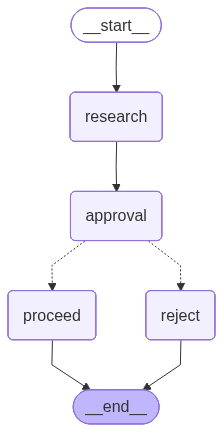

In [7]:
# Visualize the Graph

from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [8]:
config = {"configurable": {"thread_id": "1"}}
response_thread_1 = workflow.invoke(
    {
        "topic" : "LangChain"
    },
    config=config,
)
print(response_thread_1.keys())

dict_keys(['topic', 'article', 'action_details', 'status', '__interrupt__'])


In [9]:
print(f" [TOPIC REQUESTED] {response_thread_1['topic']}")
print(f" [CURRENT STATUS] {response_thread_1['status']}")
print(f" [ACTION DETAILS] {response_thread_1['action_details']}")
print(f" [ARTICLE GENERATED]\n {response_thread_1['article']}")

 [TOPIC REQUESTED] LangChain
 [CURRENT STATUS] pending
 [ACTION DETAILS] ['Article on LangChain topic has been generated']
 [ARTICLE GENERATED]
 LangChain is a framework designed for building applications that leverage large language models (LLMs). It provides tools for integrating LLMs with various data sources, APIs, and workflows. The framework supports features like prompt management, memory, and chaining of multiple LLM calls. LangChain aims to simplify the development of complex applications by providing modular components. It is particularly useful for tasks such as chatbots, data analysis, and content generation.


In [10]:
print(response_thread_1["__interrupt__"])

[Interrupt(value={'question': 'Approve this action?', 'details': ['Article on LangChain topic has been generated']}, id='b984c861f06e87ba343ff4af5b4e661c')]


In [11]:
config = {"configurable": {"thread_id": "2"}}
response_thread_2 = workflow.invoke(
    {
        "topic" : "LangGraph"
    },
    config=config,
)

print(f" [TOPIC REQUESTED] {response_thread_2['topic']}")
print(f" [CURRENT STATUS] {response_thread_2['status']}")
print(f" [ACTION DETAILS] {response_thread_2['action_details']}")
print(f" [ARTICLE GENERATED]\n {response_thread_2['article']}")

 [TOPIC REQUESTED] LangGraph
 [CURRENT STATUS] pending
 [ACTION DETAILS] ['Article on LangGraph topic has been generated']
 [ARTICLE GENERATED]
 LangGraph is a framework designed to enhance natural language processing tasks by representing language data as graphs. It captures relationships between words, phrases, and concepts, enabling more nuanced understanding and manipulation of language. By leveraging graph structures, LangGraph facilitates tasks such as semantic analysis, information retrieval, and knowledge representation. Its flexibility allows integration with various machine learning models, improving performance in language-related applications. Overall, LangGraph aims to bridge the gap between linguistic theory and computational methods.


In [12]:
print(response_thread_2["__interrupt__"])

[Interrupt(value={'question': 'Approve this action?', 'details': ['Article on LangGraph topic has been generated']}, id='f4032aff9559443f9784ec03eb2844c9')]


### **Resuming interrupts**

After an interrupt pauses execution, you resume the graph by invoking it again with a Command that contains the resume value. The resume value is passed back to the interrupt call, allowing the node to continue execution with the external input.

**Note:** When you resume the graph, pass `True` to approve or `False` to reject.

Also note that `interrupt()` returns whatever you pass in the `Command(resume=...)`

In [13]:
config = {"configurable": {"thread_id": "2"}}

resumed_response_thread_2 = workflow.invoke(Command(resume=True), config=config)

print(resumed_response_thread_2)

{'topic': 'LangGraph', 'article': 'LangGraph is a framework designed to enhance natural language processing tasks by representing language data as graphs. It captures relationships between words, phrases, and concepts, enabling more nuanced understanding and manipulation of language. By leveraging graph structures, LangGraph facilitates tasks such as semantic analysis, information retrieval, and knowledge representation. Its flexibility allows integration with various machine learning models, improving performance in language-related applications. Overall, LangGraph aims to bridge the gap between linguistic theory and computational methods.', 'action_details': ['Article on LangGraph topic has been generated', 'User has given the decision', 'Appoved'], 'status': 'approved'}


In [14]:
print(f" [TOPIC REQUESTED] {resumed_response_thread_2['topic']}")
print(f" [CURRENT STATUS] {resumed_response_thread_2['status']}")
print(f" [ACTION DETAILS] {resumed_response_thread_2['action_details']}")
print(f" [ARTICLE GENERATED]\n {resumed_response_thread_2['article']}")

 [TOPIC REQUESTED] LangGraph
 [CURRENT STATUS] approved
 [ACTION DETAILS] ['Article on LangGraph topic has been generated', 'User has given the decision', 'Appoved']
 [ARTICLE GENERATED]
 LangGraph is a framework designed to enhance natural language processing tasks by representing language data as graphs. It captures relationships between words, phrases, and concepts, enabling more nuanced understanding and manipulation of language. By leveraging graph structures, LangGraph facilitates tasks such as semantic analysis, information retrieval, and knowledge representation. Its flexibility allows integration with various machine learning models, improving performance in language-related applications. Overall, LangGraph aims to bridge the gap between linguistic theory and computational methods.


In [15]:
config = {"configurable": {"thread_id": "1"}}

resumed_response_thread_1 = workflow.invoke(Command(resume=False), config=config)

print(f" [TOPIC REQUESTED] {resumed_response_thread_1['topic']}")
print(f" [CURRENT STATUS] {resumed_response_thread_1['status']}")
print(f" [ACTION DETAILS] {resumed_response_thread_1['action_details']}")
print(f" [ARTICLE GENERATED]\n {resumed_response_thread_1['article']}")

 [TOPIC REQUESTED] LangChain
 [CURRENT STATUS] rejected
 [ACTION DETAILS] ['Article on LangChain topic has been generated', 'User has given the decision', 'Rejected']
 [ARTICLE GENERATED]
 LangChain is a framework designed for building applications that leverage large language models (LLMs). It provides tools for integrating LLMs with various data sources, APIs, and workflows. The framework supports features like prompt management, memory, and chaining of multiple LLM calls. LangChain aims to simplify the development of complex applications by providing modular components. It is particularly useful for tasks such as chatbots, data analysis, and content generation.
